<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB40 · Motores de verdad y control PD

**Parte 5 · La física del cuerpo — Lección 5**

> En el **NB37** viste que los motores de Hopper hacen un **par** de hasta 200 N·m, y en el **NB38** convertiste sus articulaciones en **muelles** para que se sostuviera como una estatua. Te dije que aquello era "hacer trampa" y que veríamos cómo lo hace un motor de verdad.

Hoy abrimos la caja del motor. Primero, cómo es **por dentro** un motor eléctrico de robot y por qué casi todos llevan **engranajes**. Después, sus **límites**, que son los que deciden lo que un robot puede y no puede hacer. Y por último, la pregunta más práctica de todas: si quiero que la rodilla se ponga a **0,8 radianes**, ¿qué le digo al motor en cada instante?

La respuesta es el **control PD**, probablemente el controlador más usado de toda la robótica. Lo vamos a construir desde cero, vamos a ver sus virtudes y sus trampas en una articulación simulada a mano, y al final lo usaremos para que Hopper se sostenga **de pie con sus propios motores**. Y descubrirás que está escondido dentro de casi todas las políticas de RL de los robots reales.


## 1 · El motor eléctrico, por dentro

Casi todos los robots usan **motores eléctricos**. La idea básica cabe en una frase: **los imanes se atraen y se repelen**.

- Has jugado con imanes: polo norte con polo sur, se atraen; norte con norte, se repelen.
- Por un cable enrollado (una **bobina**) que lleva **corriente eléctrica** se crea también un imán, un **electroimán**: tiene norte y sur mientras pasa la corriente, y deja de ser imán al cortarla. Si la corriente va al revés, sus polos se invierten.

Un motor eléctrico pone **imanes** en una pieza que puede girar (el **rotor**) y **bobinas** alrededor, en la parte fija (el **estátor**). Un pequeño ordenador va encendiendo y apagando las bobinas en el orden justo para que siempre estén **tirando** de los imanes del rotor un poco por delante de donde están, como una zanahoria delante de un burro. El rotor nunca alcanza la zanahoria: gira y gira.

```
            bobina (encendida: tira)
                 ▓▓
          ▓▓   ╱  N  ╲   ▓▓     ← las bobinas del estátor, alrededor
              │ S   N │          ← el rotor, con imanes, gira en el centro
          ▓▓   ╲  S  ╱   ▓▓
                 ▓▓
```

Lo más importante para nosotros: **el par que hace el motor es proporcional a la corriente** que pasa por sus bobinas. El doble de corriente, el doble de par. Por eso un controlador "manda par" a un motor mandándole **corriente**.

Y una característica que lo complica todo: un motor eléctrico pequeño gira **muy deprisa** (miles de vueltas por minuto) pero con **muy poco par**. Justo lo contrario de lo que necesita una rodilla, que gira despacio pero tiene que levantar un cuerpo entero.


## 2 · La reductora: cambiar velocidad por fuerza

La solución son los **engranajes**: ruedas con dientes que encajan unas con otras. Si una rueda **pequeña** (la del motor) mueve a una **grande** (la de la articulación):

- La grande gira **más despacio**: si tiene 50 dientes y la pequeña 1... bueno, digamos 10 y 500, la grande da una vuelta por cada **50** de la pequeña.
- Pero gira con **más par**: 50 veces más (¡la llave inglesa del NB37! los dientes de la rueda grande están más lejos de su eje, con un brazo de palanca mayor).

A ese conjunto de engranajes se le llama **reductora**, y al número (aquí 50) se le llama **relación de reducción**, y se escribe **50:1**. Es lo mismo que hacen las **marchas** de una bici: con la marcha corta, subes una cuesta pedaleando mucho y avanzando poco (más fuerza, menos velocidad).

```
   par en la articulación      =  par del motor       ×  N
   velocidad en la articulación =  velocidad del motor ÷  N
```

Un ejemplo con números realistas: un motor que da **0,5 N·m** de par girando a **3.000 vueltas por minuto** (rpm), con una reductora de **50:1**. Primero, el par:


In [1]:
import math

par_motor = 0.5             # N·m
N = 50
print(par_motor * N, "N·m en la articulación")

25.0 N·m en la articulación


**25 N·m**: suficiente para una articulación de un robot pequeño. Ahora la velocidad. Las rpm hay que pasarlas a radianes por segundo (NB36, NB37): una vuelta son 2π radianes, y un minuto, 60 segundos:

In [2]:
rpm_motor = 3000
rad_s_motor = rpm_motor * 2 * math.pi / 60
print(round(rad_s_motor, 1), "rad/s el motor  →", round(rad_s_motor / N, 2), "rad/s la articulación")

314.2 rad/s el motor  → 6.28 rad/s la articulación


El motor gira a 314 rad/s; la articulación, a **6,28 rad/s**: una vuelta por segundo. Para una rodilla, más que suficiente (tu rodilla, al correr, se mueve más o menos así de rápido).

### El precio de la reductora

Nada es gratis. Una reductora tiene tres costes importantes:

1. **Rozamiento**: los dientes rozan entre sí y se pierde parte del par (y se calienta).
2. **Holgura**: entre diente y diente hay un poquito de juego. Si cambias de sentido, la articulación "baila" un pelín antes de que los dientes vuelvan a encajar. Para un control preciso, molesta.
3. **Inercia reflejada**: el rotor del motor, visto desde la articulación, parece **N² veces** más pesado de girar (las cuentas de inercia de giro del NB37 con la velocidad multiplicada por N). Con N = 50, ¡2.500 veces! Eso hace que la articulación sea **dura**: si la empujas con la mano (o si el pie choca con el suelo), no cede. Se dice que **no es retroimpulsable** (*backdrivable*: que se pueda mover desde fuera).

Lo tercero es crucial para robots con patas. Un pie que golpea el suelo con una pierna **dura** recibe un golpe tremendo, que puede romper los engranajes. Por eso, a partir de 2015, el laboratorio del **MIT** con sus robots **Cheetah** (y después empresas como **Unitree**) popularizó los **actuadores cuasi-directos**: motores muy anchos y potentes con reductoras **pequeñas** (alrededor de 6:1). Son retroimpulsables: la pierna cede un poco al golpear el suelo, como un músculo, y el propio motor puede **sentir** las fuerzas que recibe midiendo su corriente. Casi todos los robots de cuatro patas modernos y muchos humanoides usan esta idea.


## 3 · Los límites de un motor

Un motor no puede dar cualquier par a cualquier velocidad. Tiene tres límites:

**1. Par máximo.** Hay una corriente máxima que aguantan las bobinas y la electrónica, así que hay un par máximo. Es el "multiplicador" (*gear*) de MuJoCo con la acción a tope: 200 N·m en Hopper.

**2. Velocidad máxima, y la recta par-velocidad.** Cuando un motor gira deprisa, él mismo genera una "corriente al revés" que frena la suya (es la misma física que hace funcionar una dinamo de bici). Resultado: **cuanto más deprisa gira, menos par puede dar**. A la velocidad máxima, ya no puede dar **nada** de par. Más o menos, la relación es una **recta**:

```
   par
    │●  par máximo (parado, haciendo fuerza)
    │  ╲
    │    ╲        el motor solo puede trabajar en la zona de debajo de la recta
    │      ╲
    │        ╲
    └──────────●──── velocidad
           velocidad máxima (girando en vacío, sin fuerza)
```

Por eso un robot no puede ser a la vez **muy fuerte** y **muy rápido** en el mismo movimiento: un salto (mucho par a mucha velocidad) está en el límite de lo que pueden dar sus motores.

**3. El calor.** La corriente calienta las bobinas. Un motor puede dar mucho par durante un **momento** (el **par de pico**), pero si lo mantiene, se calienta hasta quemarse. El par que puede mantener **indefinidamente** (el **par continuo**) es bastante menor, a menudo la tercera parte o menos. Un robot humanoide que se queda mucho rato de pie con las rodillas dobladas está calentando sus motores de rodilla todo el rato: es un problema real, y muchos robots tienen que **sentarse a descansar**.

Ninguno de estos límites está en los entornos de Gymnasium del NB35 (solo el primero, el par máximo). Es una de las razones del **reality gap** (NB02): una política entrenada en simulación puede pedir movimientos que los motores reales no pueden hacer. Los profesionales los añaden al simulador.


## 4 · Mandar a un ángulo: el problema

Ahora, la pregunta práctica. Una articulación (digamos, una pierna colgando de la cadera) está en un ángulo, y queremos llevarla a un **ángulo objetivo**, por ejemplo **0,8 radianes**. Lo único que podemos hacer es decirle al motor **cuánto par** dar en cada instante. ¿Qué par le decimos?

Vamos a simularlo a mano, con lo del NB37. La pierna será un palo de **2 kg** y **0,5 m** que cuelga de la cadera, y su ángulo θ se mide desde la vertical hacia abajo (colgando recta = 0, como en el NB36). Sobre ella actúan dos pares:

- el del **motor**, que decidimos nosotros;
- el de la **gravedad**, que tira de ella hacia abajo, hacia θ = 0: −m × g × (L/2) × sin θ (el del NB37, con el signo menos porque la devuelve hacia abajo).

Y la aceleración de giro es el par total entre la inercia de giro (m × L² / 3, NB37). Las constantes:


In [3]:
import numpy as np
import matplotlib.pyplot as plt

g = 9.81
masa, largo = 2.0, 0.5
inercia = masa * largo ** 2 / 3          # palo que gira por un extremo (NB37)
paso = 0.001

Y la simulación, con un hueco para el **controlador**: una función que recibe el ángulo y la velocidad de giro y devuelve el par del motor. Así podremos probar controladores distintos sin tocar la física:

In [4]:
def simular_pierna(controlador, duracion=2.0, limite_par=None):
    theta, velocidad = 0.0, 0.0                     # empieza colgando recta y quieta
    tiempos, angulos = [], []
    for i in range(round(duracion / paso)):
        par_motor = controlador(theta, velocidad)
        if limite_par is not None:                  # el motor tiene un par máximo
            par_motor = max(-limite_par, min(limite_par, par_motor))
        par_gravedad = -masa * g * (largo / 2) * math.sin(theta)
        aceleracion = (par_motor + par_gravedad) / inercia
        velocidad = velocidad + aceleracion * paso
        theta = theta + velocidad * paso
        tiempos.append((i + 1) * paso)
        angulos.append(theta)
    return tiempos, angulos

(`max(-limite, min(limite, x))` "recorta" x para que no se salga de ±límite: la saturación del motor. De momento no la usamos.)


## 5 · El control P: un muelle

La idea más natural del mundo: **cuanto más lejos estás del objetivo, más fuerte empujas hacia él**.

```
   par  =  Kp  ×  (objetivo − ángulo)
```

La diferencia (objetivo − ángulo) se llama **error**: cuánto te falta. Si te falta mucho, empujas mucho; si te falta poco, poco; si te has pasado, el error es negativo y empujas hacia atrás. **Kp** es un número que decide **cuánto** par por cada radián de error: se llama **ganancia proporcional** (por eso la **P**: proporcional).

¿Te suena? Es **exactamente** lo que hace un **muelle**: cuanto más lo estiras, más fuerte tira para volver. El control P convierte el motor en un muelle invisible que une la articulación con el ángulo objetivo. Probémoslo con Kp = 50:


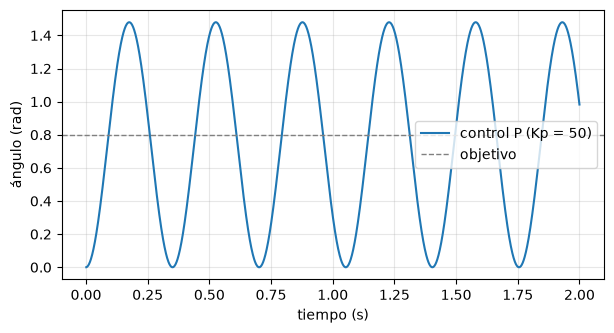

In [5]:
OBJETIVO = 0.8

def control_p(theta, velocidad):
    return 50 * (OBJETIVO - theta)

t, a = simular_pierna(control_p)
plt.figure(figsize=(7, 3.5))
plt.plot(t, a, label="control P (Kp = 50)")
plt.axhline(OBJETIVO, color="gray", ls="--", lw=1, label="objetivo")
plt.xlabel("tiempo (s)")
plt.ylabel("ángulo (rad)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

¡Un desastre! La pierna sube, se **pasa** del objetivo (hasta casi 1,5 rad), vuelve, se pasa por abajo, vuelve... y oscila **para siempre**, sin pararse nunca.

Tiene toda la lógica: es un **muelle**. Si estiras un muelle con un peso colgado y lo sueltas, rebota arriba y abajo. Y aquí no hay **nada** que frene el movimiento (no hemos puesto rozamiento): cuando la pierna llega al objetivo, lleva velocidad, y la **inercia** (NB02) la hace pasarse. Le falta lo que tiene un coche junto a cada muelle de su suspensión: un **amortiguador**.


## 6 · El control PD: muelle + amortiguador

El amortiguador es un par que **frena** según lo deprisa que se mueve la articulación:

```
   par  =  Kp × (objetivo − ángulo)   −   Kd × velocidad de giro
           ─────────────────────────      ────────────────────────
             P: el muelle                  D: el amortiguador
```

Si la articulación se mueve deprisa, el término D empuja **en contra** del movimiento, como meter la mano en agua: cuanto más rápido la mueves, más te frena. **Kd** es la **ganancia derivativa** (la **D**: la velocidad es la **derivada** del ángulo, la pendiente del NB16). Con las dos, el controlador se llama **PD**.

Probemos el mismo muelle (Kp = 50) con amortiguadores cada vez más fuertes. Como vamos a hacer varios controladores, una función que los **fabrica** (una función que devuelve una función, NB23):


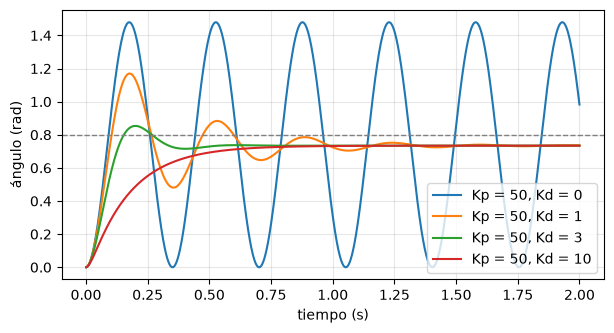

In [6]:
def fabrica_pd(Kp, Kd):
    def controlador(theta, velocidad):
        return Kp * (OBJETIVO - theta) - Kd * velocidad
    return controlador

plt.figure(figsize=(7, 3.5))
for Kd in [0, 1, 3, 10]:
    t, a = simular_pierna(fabrica_pd(50, Kd))
    plt.plot(t, a, label=f"Kp = 50, Kd = {Kd}")
plt.axhline(OBJETIVO, color="gray", ls="--", lw=1)
plt.xlabel("tiempo (s)")
plt.ylabel("ángulo (rad)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

- **Kd = 0**: el control P de antes, oscilando para siempre.
- **Kd = 1**: oscila, pero cada vez menos, y se acaba calmando. Amortiguador **flojo**.
- **Kd = 3**: sube, se pasa un poquito y se queda quieto enseguida. Un buen equilibrio.
- **Kd = 10**: sube **sin pasarse nada**, pero más despacio. Amortiguador **fuerte**: como mover la mano en miel.

Elegir Kp y Kd se llama **ajustar** (*tuning*) el controlador, y es una de las tareas del día a día de un ingeniero de robots:

- **Kp** alto: articulación **rígida** y rápida, pero propensa a oscilar y a dar golpes. Kp bajo: **blanda**, se deja empujar.
- **Kd** alto: movimientos suaves, sin rebotes, pero lentos (y amplifica el ruido de los sensores, NB41). Kd bajo: rápido pero con rebotes.


## 7 · La trampa de la gravedad

Mira otra vez la gráfica: con Kd = 3 o 10, la pierna se queda quieta... pero **no en 0,8**. Se queda un poco por **debajo**. Midámoslo, con tres Kp distintos:


In [7]:
for Kp in [20, 50, 200]:
    t, a = simular_pierna(fabrica_pd(Kp, 0.3 * math.sqrt(Kp)), duracion=4.0)
    print(f"Kp = {Kp:3d}:  se queda en {a[-1]:.3f} rad  (le faltan {OBJETIVO - a[-1]:.3f})")

Kp =  20:  se queda en 0.651 rad  (le faltan 0.149)
Kp =  50:  se queda en 0.734 rad  (le faltan 0.066)
Kp = 200:  se queda en 0.783 rad  (le faltan 0.017)


(Para cada Kp usamos un Kd proporcional a su raíz cuadrada, que es una forma razonable de mantener el mismo "carácter" del amortiguador al cambiar el muelle.)

Nunca llega del todo. ¿Por qué? Porque la **gravedad** tira de la pierna hacia abajo, y el control P solo empuja hacia arriba **si hay error**: el muelle tiene que estar **un poco estirado** para sostener el peso, como un muelle del que cuelgas una pesa, que queda un poco más largo que sin ella. La pierna se queda donde el par del muelle (Kp × error) iguala al de la gravedad. Con un muelle más duro (Kp mayor), hace falta menos error para lo mismo: con Kp = 200 se queda a solo 0,017 rad. A este error que no desaparece se le llama **error estacionario**.

Hay dos formas de arreglarlo:

1. **El término I** (de **integral**): ir **acumulando** el error con el tiempo y empujar más cuanto más rato llevas sin llegar. Con él, el controlador se llama **PID**, y es el controlador más famoso de la ingeniería (está en los termostatos, en los drones, en los hornos industriales...). Pero en robots con patas se usa poco, porque los contactos con el suelo lo vuelven loco.
2. **Compensar la gravedad**: si **sabemos** cuánto par hace la gravedad (¡lo sabemos, NB37!), se lo **sumamos** al motor por adelantado. El PD solo tiene que corregir lo que queda. A esto se le llama **prealimentación** (*feedforward*): adelantarse a lo que sabes que va a pasar.


In [8]:
def pd_con_gravedad(theta, velocidad):
    pd = 50 * (OBJETIVO - theta) - 3 * velocidad
    gravedad = masa * g * (largo / 2) * math.sin(theta)        # el par que hace falta para sostener la pierna
    return pd + gravedad

t, a = simular_pierna(pd_con_gravedad, duracion=4.0)
print(f"con compensación de gravedad: se queda en {a[-1]:.3f} rad")

con compensación de gravedad: se queda en 0.800 rad


**0,800**: exacto. Así lo hacen muchos robots reales: un modelo de la física (lo que hemos aprendido en esta parte) para el grueso del trabajo, y un PD para corregir los errores del modelo.


## 8 · Cuando el motor no da más

Por último, el mundo real: el motor tiene un **par máximo** (sección 3). Para sostener la pierna en 0,8 rad hacen falta unos 3,5 N·m solo contra la gravedad:

In [9]:
print(round(masa * g * (largo / 2) * math.sin(OBJETIVO), 2), "N·m")

3.52 N·m


¿Qué pasa si el motor solo puede dar **2,5 N·m**? Un PD fuerte (Kp = 200, Kd = 6), con y sin ese límite:

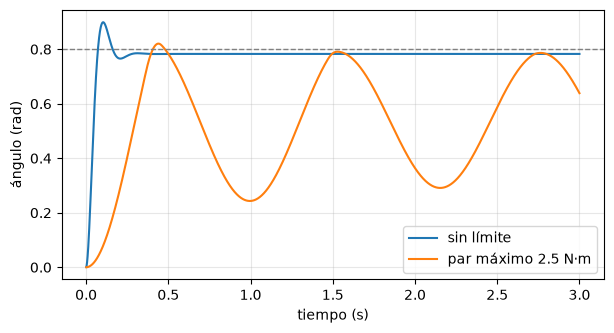

In [10]:
plt.figure(figsize=(7, 3.5))
for limite in [None, 2.5]:
    t, a = simular_pierna(fabrica_pd(200, 6), duracion=3.0, limite_par=limite)
    plt.plot(t, a, label="sin límite" if limite is None else f"par máximo {limite} N·m")
plt.axhline(OBJETIVO, color="gray", ls="--", lw=1)
plt.xlabel("tiempo (s)")
plt.ylabel("ángulo (rad)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Sin límite, la pierna llega cerca del objetivo en un instante. Con el motor limitado a 2,5 N·m, **no puede quedarse** en el objetivo: con el impulso de la subida llega a tocar los 0,8 rad un instante, pero allí arriba la gravedad hace más par (3,5 N·m) del que el motor puede dar (el motor está a tope: se dice que está **saturado**). La pierna cae hasta unos 0,25 rad, el motor la vuelve a subir, vuelve a caer... y se queda **columpiándose** para siempre, sin poder sostenerse arriba. Ningún ajuste de Kp y Kd lo arregla: es un límite **físico**. La única salida es otro motor, otra reductora (sección 2) o pedirle a la pierna algo menos ambicioso.

Por eso, cuando un robot real no hace lo que su controlador le pide, lo primero que mira un ingeniero es: **¿está saturado algún motor?**


## 9 · Hopper, de pie con sus propios motores

Ahora, el robot de verdad. En el NB38 sostuvimos a Hopper como una estatua convirtiendo sus articulaciones en muelles con `jnt_stiffness` (la **rigidez**) y `dof_damping` (la **amortiguación**). Míralo con los ojos de hoy: **¡aquello era un PD!** Rigidez = Kp, amortiguación = Kd, postura del muelle = objetivo. Solo que lo hacía MuJoCo "por arte de magia", sin motores.

Ahora lo hacemos de verdad: un PD que, en cada pasito, calcula el par para cada una de sus tres articulaciones y se lo **pide a sus motores** a través de `datos.ctrl` (la acción del NB35). Como sus motores tienen un multiplicador de 200 y la acción va de −1 a 1, hay que dividir el par entre 200 y recortarlo a ±1 (la saturación):


In [11]:
import os
os.environ["MUJOCO_GL"] = "egl"
import gymnasium as gym
import mujoco

hopper = gym.make("Hopper-v5")
modelo = hopper.unwrapped.model
datos = hopper.unwrapped.data

In [12]:
def hopper_con_pd(Kp, Kd, pasos=1500):
    hopper.reset(seed=0)
    objetivo = np.zeros(3)                          # cadera, rodilla y tobillo a 0: de pie y recto
    datos.qpos[:] = [0.0, 1.25, 0.0, 0.0, 0.0, 0.0]
    datos.qvel[:] = 0
    mujoco.mj_forward(modelo, datos)
    datos.qpos[1] -= datos.joint("foot_joint").xanchor[2] - 0.0605      # pie apoyado (NB38)
    for i in range(pasos):
        angulos = datos.qpos[3:6]                   # los ángulos de las tres articulaciones
        velocidades = datos.qvel[3:6]               # y sus velocidades de giro
        par = Kp * (objetivo - angulos) - Kd * velocidades          # ¡el PD!
        datos.ctrl[:] = np.clip(par / 200, -1, 1)                    # a sus motores, con saturación
        mujoco.mj_step(modelo, datos)
    return datos.qpos[2]                            # inclinación final del torso

(`np.clip(x, -1, 1)` recorta cada número a ±1, como el `max(min(...))` de antes pero para listas enteras. `datos.qvel` es la lista de **velocidades** de MuJoCo, hermana de `qpos`.)

Ojo a lo que **no** hacemos: no llamamos a `hopper.step` (que repetiría la misma acción 4 pasitos, NB35), sino a `mujoco.mj_step` directamente, para que el PD corrija **en cada pasito** de 0,002 s: 500 veces por segundo. Probemos tres ajustes:


In [13]:
for Kp, Kd in [(0, 0), (50, 5), (300, 20)]:
    inclinacion = hopper_con_pd(Kp, Kd)
    print(f"Kp = {Kp:3d}, Kd = {Kd:2d}:  inclinación final del torso {inclinacion:+.3f} rad  →  {'DE PIE' if abs(inclinacion) < 0.3 else 'SE CAE'}")

Kp =   0, Kd =  0:  inclinación final del torso -2.225 rad  →  SE CAE
Kp =  50, Kd =  5:  inclinación final del torso -1.181 rad  →  SE CAE
Kp = 300, Kd = 20:  inclinación final del torso -0.008 rad  →  DE PIE


- **Kp = 0**: motores apagados. Muñeco de trapo, como en el NB35.
- **Kp = 50**: el muelle es demasiado **blando** para un robot de 16 kg: las articulaciones ceden bajo su peso (error estacionario enorme, sección 7) y se derrumba.
- **Kp = 300, Kd = 20**: articulaciones lo bastante rígidas. **¡De pie!**, sostenido por sus propios motores.

Veámoslo:


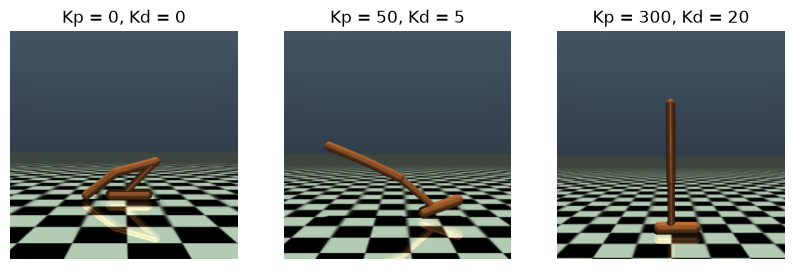

In [14]:
fig, ejes = plt.subplots(1, 3, figsize=(10, 3.6))
with mujoco.Renderer(modelo, height=300, width=300) as camara:
    for eje, (Kp, Kd) in zip(ejes, [(0, 0), (50, 5), (300, 20)]):
        hopper_con_pd(Kp, Kd)
        camara.update_scene(datos, camera="track")
        eje.imshow(camara.render())
        eje.set_title(f"Kp = {Kp}, Kd = {Kd}")
        eje.axis("off")
plt.show()

Fíjate en lo que **no** hace este PD: **no** sabe nada de equilibrio. Solo mantiene los ángulos de las articulaciones. Si empujas a este Hopper con fuerza, se caerá como una estatua, porque no dará ningún paso (NB39). El PD es el "músculo obediente"; el que decide **qué ángulos** pedir para no caerse y para andar es otro: la **política**.


## 10 · El PD dentro del aprendizaje por refuerzo

Y aquí llega la conexión con todo lo anterior. En el NB35, la política de Hopper decidía directamente el **par** de cada motor (la acción era "cuánto par, de −1 a 1"). Funciona en simulación, pero en los **robots reales** casi nunca se hace así. Lo habitual es:

```
   política (50 veces por segundo)                 PD (500 a 1.000 veces por segundo)
   ─────────────────────────────────                ───────────────────────────────────
   mira la observación y decide los      ──────►   persigue esos ángulos con los
   ÁNGULOS OBJETIVO de cada articulación            motores: par = Kp·error − Kd·velocidad
```

La política ya no da pares, sino **ángulos objetivo**, y un PD rapidísimo los convierte en pares. ¿Por qué?

- **Es más fácil de aprender.** Con la acción a cero, la política pide "la postura de pie" y el PD la sostiene. Con pares, la acción cero es el muñeco de trapo, y la política tiene que aprender **desde cero** a no derrumbarse.
- **Es más seguro.** El PD actúa como un muelle: si la política dice una tontería, el movimiento es suave y limitado, no un latigazo de par máximo.
- **Separa lo rápido de lo lento.** La red neuronal es lenta de calcular y decide 50 veces por segundo; el PD es una cuenta de nada y corrige centenares de veces por segundo, absorbiendo los golpes del suelo.
- **Transfiere mejor a la realidad.** Los motores reales ya traen un PD en su electrónica; entrenar así es entrenar como luego se usará.

Los entornos de entrenamiento de robots reales (como los de Isaac Lab o MuJoCo Playground, que usaremos en la parte de bípedos) funcionan así. Y Kp y Kd, como ves, son dos hiperparámetros más (NB34) que hay que elegir bien: un PD demasiado blando o demasiado rígido arruina el entrenamiento. MuJoCo incluso tiene motores "de posición" que llevan el PD dentro (`position`, con su `kp`), que verás en el NB42.


## 11 · Resumen de la lección

1. **Motor eléctrico**: imanes en el rotor, bobinas en el estátor, encendidas en orden para tirar del rotor. **Par proporcional a la corriente.** Rápido y flojo.
2. **Reductora** de N:1: par × N, velocidad ÷ N (marchas de bici). Ejemplo: 0,5 N·m y 3.000 rpm con 50:1 → 25 N·m y 6,28 rad/s.
3. Precio de la reductora: **rozamiento**, **holgura**, **inercia reflejada** (× N²) → no **retroimpulsable**. Los **actuadores cuasi-directos** (MIT Cheetah, Unitree; ~6:1) ceden como un músculo.
4. Límites: **par máximo**, **recta par-velocidad** (más rápido = menos par), **calor** (par de pico vs par continuo). Faltan en la mayoría de simuladores → reality gap.
5. **Control P**: par = Kp × error. Es un **muelle**: sin freno, oscila para siempre.
6. **Control PD**: par = Kp × error − Kd × velocidad. Muelle + **amortiguador**. Kp = rigidez; Kd = suavidad. **Ajustar** = elegirlos.
7. **Error estacionario** por la gravedad (0,651 / 0,734 / 0,783 de 0,8 con Kp 20 / 50 / 200). Arreglos: término **I** (**PID**) o **compensación de gravedad** (prealimentación): 0,800 exacto.
8. **Saturación**: si el motor no da el par necesario, ningún ajuste lo arregla.
9. **Hopper de pie** con un PD en sus motores reales (`ctrl`, cada pasito): Kp 0 y 50 se caen; Kp 300, Kd 20 se sostiene. La estatua del NB38 era un PD.
10. En robots reales, la **política da ángulos objetivo** (~50 Hz) y un **PD** los persigue (~500-1.000 Hz).

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **Electroimán / bobina** | Cable enrollado que se vuelve imán al pasar corriente. |
| **Rotor / estátor** | La parte que gira (con imanes) / la parte fija (con bobinas). |
| **Reductora, relación N:1** | Engranajes que multiplican el par por N y dividen la velocidad entre N. |
| **rpm** | Revoluciones (vueltas) por minuto. |
| **Holgura** | Juego entre los dientes de los engranajes. |
| **Inercia reflejada** | La inercia del motor vista desde la articulación: × N². |
| **Retroimpulsable (*backdrivable*)** | Que se puede mover empujando desde fuera. |
| **Actuador cuasi-directo** | Motor potente con reductora pequeña, retroimpulsable. |
| **Recta par-velocidad** | Cuanto más rápido gira un motor, menos par puede dar. |
| **Par de pico / par continuo** | El máximo por un momento / el que aguanta sin quemarse. |
| **Error** | Objetivo − valor actual. |
| **Control P / PD / PID** | Proporcional / + derivativo (amortiguador) / + integral (acumula el error). |
| **Ganancias Kp, Kd** | Cuánto par por radián de error / por rad/s de velocidad. |
| **Ajustar (*tuning*)** | Elegir las ganancias de un controlador. |
| **Error estacionario** | Error que queda para siempre (aquí, por la gravedad). |
| **Prealimentación (*feedforward*)** | Añadir por adelantado un par que sabes que hará falta. |
| **Saturación** | El controlador pide más de lo que el motor puede dar. |
| **`datos.ctrl` / `datos.qvel`** | En MuJoCo: las acciones de los motores / las velocidades. |


## 12 · Ejercicios

**E1.** Un motor da 0,8 N·m a 4.000 rpm. Con una reductora de 30:1, ¿qué par y qué velocidad (en rad/s) tiene la articulación? ¿Y con 9:1?

**E2.** Una bici: con el plato de 40 dientes delante y el piñón de 20 detrás, ¿cuántas vueltas da la rueda por cada vuelta de pedal? ¿Y con un piñón de 40? ¿Cuál usarías para subir una cuesta?

**E3.** En `simular_pierna`, prueba un PD con Kp = 50 y un Kd **negativo** (por ejemplo −1). ¿Qué pasa? Explica por qué con la idea del amortiguador.

**E4.** Con el PD (Kp = 50, Kd = 3) y **sin** compensación de gravedad, cambia el objetivo a 1,5 rad. ¿El error estacionario es mayor o menor que con 0,8? ¿Por qué? (Pista: el par de la gravedad depende de sin θ.)

**E5.** Busca, para Hopper, el Kp más pequeño (de 50 en 50, con Kd = Kp / 15) con el que se queda de pie.

**E6.** **Reto.** Sustituye en `simular_pierna` el par del motor por la **recta par-velocidad**: el par máximo que puede dar el motor es 5 × (1 − |velocidad| / 8) (5 N·m parado, 0 a 8 rad/s). Con un PD fuerte (Kp = 200, Kd = 6) hacia 0,8 rad, ¿llega? ¿Tarda más que sin el límite?


<details>
<summary>▶ Solución E1</summary>

```python
for N in [30, 9]:
    print(N, ":", 0.8 * N, "N·m,", round(4000 * 2 * math.pi / 60 / N, 2), "rad/s")
```

Con 30:1: **24 N·m** a **13,96 rad/s**. Con 9:1: **7,2 N·m** a **46,5 rad/s**. La reductora no crea nada: **reparte**. Más par, menos velocidad, o al revés. (La "potencia", par × velocidad, es la misma en los dos casos, menos lo que se pierde por rozamiento.)
</details>

<details>
<summary>▶ Solución E2</summary>

Con plato de 40 y piñón de 20: cada vuelta de pedal mueve 40 dientes, que son **2** vueltas del piñón (y de la rueda). Con piñón de 40: **1** vuelta. Para subir una cuesta, el piñón **grande** (40): la rueda gira menos por cada pedalada, pero con el doble de par. Es una reductora 1:1 frente a una "multiplicadora" 1:2 en el primer caso: las bicis normalmente **multiplican** la velocidad, al revés que los robots.
</details>

<details>
<summary>▶ Solución E3</summary>

```python
t, a = simular_pierna(fabrica_pd(50, -1))
print(max(a), a[-1])
```

Las oscilaciones **crecen** sin parar: la pierna da vueltas cada vez más violentas (el ángulo final es enorme). Un Kd negativo es un "amortiguador al revés": en vez de frenar el movimiento, lo **empuja** en el mismo sentido, metiendo energía en cada vaivén. Es como empujar un columpio justo en el momento bueno. En un robot real, un signo cambiado en un controlador hace que la articulación empiece a vibrar cada vez más fuerte hasta romperse: es uno de los errores más peligrosos (y más típicos) al programar robots. Por eso siempre se prueba primero con ganancias pequeñas.
</details>

<details>
<summary>▶ Solución E4</summary>

```python
OBJETIVO = 1.5
t, a = simular_pierna(fabrica_pd(50, 3), duracion=4.0)
print(round(OBJETIVO - a[-1], 3))
OBJETIVO = 0.8         # lo devolvemos a su valor
```

El error es **mayor**: casi 0,1 rad (0,097), frente a 0,066 con 0,8. Con la pierna más levantada (1,5 rad, casi horizontal), la gravedad hace **más par** (sin 1,5 ≈ 1, frente a sin 0,8 ≈ 0,72), así que el muelle tiene que estirarse más para aguantarla. El error estacionario depende de la postura: por eso la compensación de gravedad, que calcula el par exacto en cada postura, es tan útil.
</details>

<details>
<summary>▶ Solución E5</summary>

```python
for Kp in range(50, 351, 50):
    inclinacion = hopper_con_pd(Kp, Kp / 15)
    print(Kp, round(inclinacion, 3), "de pie" if abs(inclinacion) < 0.3 else "se cae")
```

Con Kp = 50 se derrumba. Con **Kp = 100** ya se sostiene, aunque con el torso algo inclinado (−0,145 rad: las articulaciones ceden un poco bajo el peso, el error estacionario de la sección 7). A partir de **150** queda prácticamente recto. Por encima, más Kp lo hace más rígido, pero no "más de pie". Ojo: este umbral depende de la postura y del peso; un robot que lleva carga necesitaría un Kp mayor, o compensación de gravedad.
</details>

<details>
<summary>▶ Solución E6</summary>

```python
def simular_pierna_recta(Kp, Kd, duracion=2.0):
    theta, velocidad = 0.0, 0.0
    angulos = []
    for i in range(round(duracion / paso)):
        par = Kp * (OBJETIVO - theta) - Kd * velocidad
        par_max = 5 * max(0.0, 1 - abs(velocidad) / 8)        # la recta par-velocidad
        par = max(-par_max, min(par_max, par))
        aceleracion = (par - masa * g * (largo / 2) * math.sin(theta)) / inercia
        velocidad = velocidad + aceleracion * paso
        theta = theta + velocidad * paso
        angulos.append(theta)
    return angulos

con_recta = simular_pierna_recta(200, 6)
t, sin_recta = simular_pierna(fabrica_pd(200, 6))
llega = lambda angulos: next(i for i, x in enumerate(angulos) if x > 0.7) * paso
print("tarda en pasar de 0,7 rad:", round(llega(sin_recta), 3), "s sin límite |", round(llega(con_recta), 3), "s con la recta")
print("ángulo final:", round(con_recta[-1], 3))
```

Llega (5 N·m bastan para sostener los ~3,5 N·m de la gravedad), pero **más despacio**: mientras se mueve deprisa, el motor no puede dar todo su par, así que acelera menos. Es la razón por la que un robot no puede hacer movimientos explosivos aunque "en reposo" sea muy fuerte. (`next(...)` busca el primer elemento que cumple una condición: el primer instante en que el ángulo pasa de 0,7.)
</details>


## 13 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

El PD de hoy usaba `datos.qpos` y `datos.qvel`: los ángulos y velocidades **exactos** que da el simulador. Un robot real no tiene esa suerte: tiene que **medirlos** con sensores, y los sensores **mienten un poco** (tienen ruido, retrasos y errores). En el **NB41** veremos los sensores de un robot (codificadores, la IMU con su acelerómetro y su giróscopo, los sensores de fuerza de los pies), qué miden de verdad, cómo es su ruido y cómo se combinan para estimar lo que no se puede medir directamente.
